In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
class scratch_logistic:
    def __init__(self,lr,epochs):
        self.W = None
        self.lr = lr
        self.epochs = epochs

    def fit(self,x_train,y_train):
        y_train = np.array(y_train)
        x_train = np.insert(x_train,0,1,axis=1)
        self.W = np.zeros(x_train.shape[1])
        m = x_train.shape[0]

        for i in range(self.epochs):
            z = np.dot(x_train,self.W)
            y_hat = 1/(1 + np.exp(-z))

            self.W = self.W + self.lr*(1/m)*np.dot((y_train - y_hat),x_train)

    def intercept(self):
        return self.W[0]
    def coef(self):
        return self.W[1:]
    
    def predict(self,x_test):
        x_test = np.insert(x_test,0,1,axis=1)
        z_pred = np.dot(x_test,self.W)
        y_pred = 1/(1 + np.exp(-z_pred))

        return np.where(y_pred >= 0.5,1,0)      

        
    

In [3]:
df = pd.read_csv("C://Users//Acer//OneDrive//Desktop//Datasets//logistic_regression_dataset.csv")
df.drop(columns=['feature_3'],inplace=True)
df.sample(5)


,feature_1,feature_2,target
48,-3.515597,-0.262591,0
73,0.764657,-1.050415,1
17,-0.244286,-1.159391,1
24,0.455564,-1.596189,1
47,1.268092,-0.461312,1


In [4]:
x = df.drop(columns=['target'])
y = df['target']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [22]:
sc_lr = scratch_logistic(lr=0.5,epochs=10000)
sc_lr.fit(x_train,y_train)
sc_lr.intercept(),sc_lr.coef()

(np.float64(-0.463762987020962), array([7.68703758, 2.4631252 ]))

In [23]:
lr = LogisticRegression(penalty=None,solver='sag',max_iter=10000)
lr.fit(x_train,y_train)
lr.intercept_,lr.coef_

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


(array([-0.4631296]), array([[7.6761879 , 2.46003893]]))

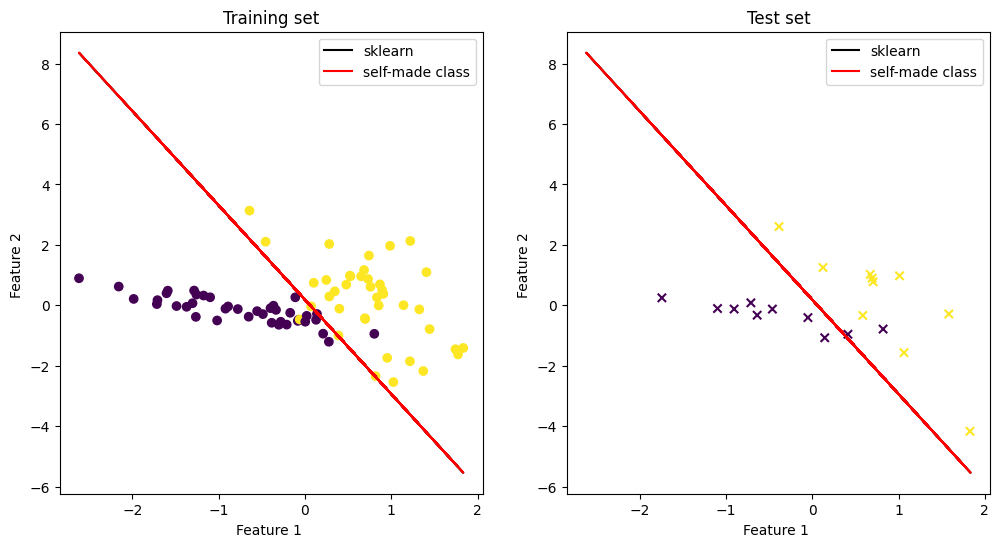

In [24]:
'''
w1x1 + w2x2 + b = 0
x2 = -(w1x1 + b)/w2
'''
x1 = x_train[:,0]
x2 = x_train[:,1]

x_test_1 = x_test[:,0]
x_test_2 = x_test[:,1]

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.scatter(x1,x2,c = y_train)

w1_sl = sc_lr.coef()[0]
w2_sl = sc_lr.coef()[1]
b_sl = sc_lr.intercept()

w1_lr = lr.coef_[0][0]
w2_lr = lr.coef_[0][1]
b_lr = lr.intercept_[0]

plt.plot(x1,-(w1_lr*x1 + b_lr)/w2_lr , c='black',label='sklearn')
plt.plot(x1,-(w1_sl*x1 + b_sl)/w2_sl , c='red',label='self-made class')
plt.xlabel("Feature 1 ")
plt.ylabel("Feature 2 ")
plt.title('Training set')
plt.legend()

plt.subplot(122)
plt.scatter(x_test_1,x_test_2,c=y_test,marker='x')
plt.plot(x1,-(w1_lr*x1 + b_lr)/w2_lr , c='black',label='sklearn')
plt.plot(x1,-(w1_sl*x1 + b_sl)/w2_sl , c='red',label='self-made class')
plt.xlabel("Feature 1 ")
plt.ylabel("Feature 2 ")
plt.title('Test set')
plt.legend()
plt.show()

In [9]:
from sklearn.metrics import accuracy_score
y_pred1 = sc_lr.predict(x_test)
y_pred2 = lr.predict(x_test)

print(f"Accuracy of self made class = {accuracy_score(y_test,y_pred1)}")
print(f"Accuracy of sklearn = {accuracy_score(y_test,y_pred2)}")

Accuracy of self made class = 0.9
Accuracy of sklearn = 0.9


In [10]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred1)

array([[ 8,  2],
       [ 0, 10]])

In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       1.00      0.80      0.89        10
           1       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



In [12]:
from sklearn.metrics import precision_score,recall_score,f1_score
p = precision_score(y_test,y_pred1)
r = recall_score(y_test,y_pred1)
f1 = (2*p*r)/(p + r)
print(f1)
print(f"sklearn = {f1_score(y_test,y_pred1)}")

0.9090909090909091
sklearn = 0.9090909090909091
